In [1]:
! pip install pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import pandas as pd
df = pd.read_csv("Iris.csv")
print(df.head())
print(df.info())
print(df.describe())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               

In [8]:
# Drop Id column (it's just row numbers, not useful for ML)
df = df.drop('Id', axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])
X = df.drop('Species', axis=1)
y = df['Species']
print(le.classes_)

[0 1 2]


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (120, 4), Test set: (30, 4)


In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Scaling complete!
X_train_scaled shape: (120, 4)


In [20]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

print("✅ Random Forest trained!")
print(f"Number of trees: {rf.n_estimators}")
print(f"Number of features: {rf.n_features_in_}")

✅ Random Forest trained!
Number of trees: 100
Number of features: 4


In [23]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on test set
y_pred = rf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 1.000 (100.0%)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [26]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]
print(indices)

[2 3 0 1]


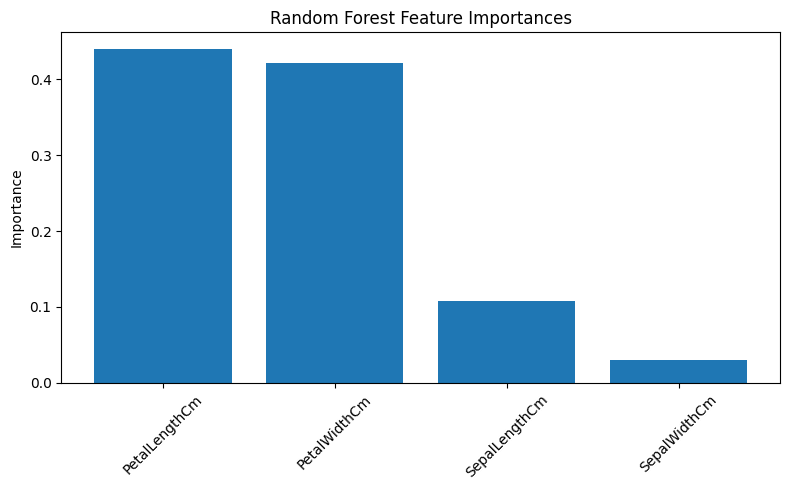

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [28]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
dt_pred = dt.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, dt_pred)
print(dt_acc)
print(f"Decision Tree Accuracy: {dt_acc:.3f} ({dt_acc*100:.1f}%)")


1.0
Decision Tree Accuracy: 1.000 (100.0%)


In [30]:
print("\nDecision Tree Report:")
print(classification_report(y_test, dt_pred))
rf_acc = accuracy_score(y_test, y_pred)


Decision Tree Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [31]:
print(f"Random Forest Accuracy: {rf_acc:.3f}")
print(f"Decision Tree Accuracy: {dt_acc:.3f}")

Random Forest Accuracy: 1.000
Decision Tree Accuracy: 1.000
